In [15]:
!pip install opendatasets --upgrade --quiet

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import opendatasets as od
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPRegressor
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import BayesianRidge
import joblib

# PRE PROCESSAMENTO DA BASE DE DADOS
Tratamento de valores que não são ideias para aprendizado de máquina, como dias de semana, para dados legíveis.

*   Meses e horas -> Timestamp
*   On/off & Yes/No -> One Hot Coding

etc....




In [17]:
# username -> gustaavv
# key -> 415ccb187e5bf342b583079752e46511

dataset_url = 'https://www.kaggle.com/datasets/mrsimple07/energy-consumption-prediction'

od.download(dataset_url)

input_file = 'energy-consumption-prediction/Energy_consumption.csv'
output_file = 'Energy_consumption_processed.csv'
df = pd.read_csv(input_file)
print(f"✅ Arquivo carregado! Shape: {df.shape}")
print(df.head())

Skipping, found downloaded files in "./energy-consumption-prediction" (use force=True to force download)
✅ Arquivo carregado! Shape: (1000, 11)
             Timestamp  Temperature   Humidity  SquareFootage  Occupancy  \
0  2022-01-01 00:00:00    25.139433  43.431581    1565.693999          5   
1  2022-01-01 01:00:00    27.731651  54.225919    1411.064918          1   
2  2022-01-01 02:00:00    28.704277  58.907658    1755.715009          2   
3  2022-01-01 03:00:00    20.080469  50.371637    1452.316318          1   
4  2022-01-01 04:00:00    23.097359  51.401421    1094.130359          9   

  HVACUsage LightingUsage  RenewableEnergy  DayOfWeek Holiday  \
0        On           Off         2.774699     Monday      No   
1        On            On        21.831384   Saturday      No   
2       Off           Off         6.764672     Sunday      No   
3       Off            On         8.623447  Wednesday      No   
4        On           Off         3.071969     Friday      No   

   Energ

In [18]:
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df = df.sort_values(by='Timestamp')

mapeamento_binario = {
    'On': 1, 'Off': 0,
    'Yes': 1, 'No': 0
}

colunas_binarias = ['HVACUsage', 'LightingUsage', 'Holiday']

print("-> Convertendo colunas binárias...")
for col in colunas_binarias:
    if col in df.columns:
        df[col] = df[col].map(mapeamento_binario).fillna(0).astype(int)


if 'DayOfWeek' in df.columns:
    df = pd.get_dummies(df, columns=['DayOfWeek'], prefix='Day')


cols_to_scale = ['Temperature', 'Humidity', 'SquareFootage', 'Occupancy', 'RenewableEnergy']

cols_existentes = [c for c in cols_to_scale if c in df.columns]

if cols_existentes:
    print("-> Padronizando variáveis numéricas...")
    scaler = StandardScaler()
    df[cols_existentes] = scaler.fit_transform(df[cols_existentes])

if 'Timestamp' in df.columns:
    df = df.drop(columns=['Timestamp'])

cols_finais = [c for c in df.columns if c != 'EnergyConsumption'] + ['EnergyConsumption']
df = df[cols_finais]

-> Convertendo colunas binárias...
-> Padronizando variáveis numéricas...


In [19]:
print("\nAmostra dos dados processados:")
display(df.head())
print(df.info())


Amostra dos dados processados:


,Temperature,Humidity,SquareFootage,Occupancy,HVACUsage,LightingUsage,RenewableEnergy,Holiday,Day_Friday,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday,EnergyConsumption
0,0.055514,-0.230642,0.227705,0.146290,1,0,-1.413722,0,False,True,False,False,False,False,False,75.364373
1,0.969738,1.037096,-0.308690,-1.250277,1,1,0.766292,0,False,False,True,False,False,False,False,83.401855
2,1.312764,1.586942,0.886871,-0.901135,0,0,-0.957284,0,False,False,False,True,False,False,False,78.270888
3,-1.728681,0.584431,-0.165593,-1.250277,0,1,-0.744647,0,False,False,False,False,False,False,True,56.519850
4,-0.664684,0.705374,-1.408109,1.542858,1,0,-1.379716,0,True,False,False,False,False,False,False,70.811732


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Temperature        1000 non-null   float64
 1   Humidity           1000 non-null   float64
 2   SquareFootage      1000 non-null   float64
 3   Occupancy          1000 non-null   float64
 4   HVACUsage          1000 non-null   int64  
 5   LightingUsage      1000 non-null   int64  
 6   RenewableEnergy    1000 non-null   float64
 7   Holiday            1000 non-null   int64  
 8   Day_Friday         1000 non-null   bool   
 9   Day_Monday         1000 non-null   bool   
 10  Day_Saturday       1000 non-null   bool   
 11  Day_Sunday         1000 non-null   bool   
 12  Day_Thursday       1000 non-null   bool   
 13  Day_Tuesday        1000 non-null   bool   
 14  Day_Wednesday      1000 non-null   bool   
 15  EnergyConsumption  1000 non-null   float64
dtypes: bool(7), float64(6), i

In [20]:
df.to_csv(output_file, index=False)
print(f"\nArquivo salvo: {output_file}")


Arquivo salvo: Energy_consumption_processed.csv


# APRENDIZADO
Medidas para fazer a regressão/predição dos valores de consumo de energia

* KNN
* Naive Bayes
* MLP
* Regressão Linear
* Random Forest


## KNN


In [21]:
resultados_finais = []

df = pd.read_csv('Energy_consumption_processed.csv')

X = df.drop(columns=['EnergyConsumption'])
y = df['EnergyConsumption']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dados preparados.")
print(f"Treino: {X_train_scaled.shape}")
print(f"Teste:  {X_test_scaled.shape}")


Dados preparados.
Treino: (800, 15)
Teste:  (200, 15)


--- Otimizando KNN com Validação Cruzada ---
K     | Média R² (CV)  
------------------------------
1     | -0.0905
2     | 0.2352
3     | 0.3127
4     | 0.3480
5     | 0.3611
6     | 0.3734
7     | 0.3906
8     | 0.3947
9     | 0.3933
10    | 0.3867
11    | 0.3882
12    | 0.3845
13    | 0.3843
14    | 0.3822
15    | 0.3754
16    | 0.3758
17    | 0.3752
18    | 0.3706
19    | 0.3680
20    | 0.3690
------------------------------
🏆 O MELHOR K (no Treino) foi: 8 (Média R²: 0.3947)

--- Resultado Final no Teste ---
R² Real: 0.4639
RMSE Real: 5.9258


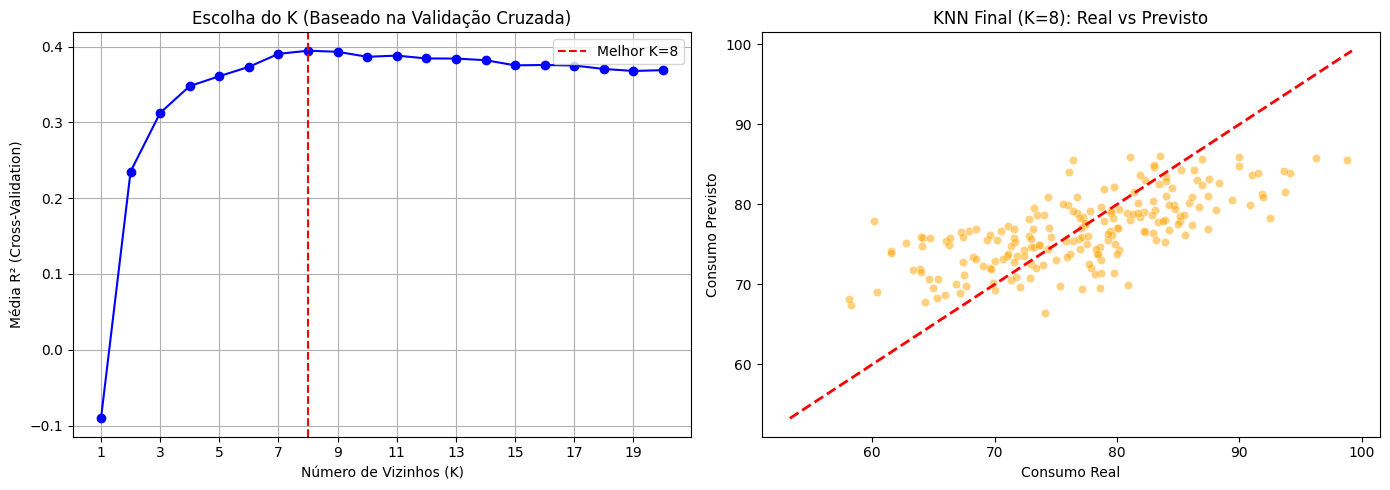

In [22]:
print("--- Otimizando KNN com Validação Cruzada ---")

# Listas para armazenar o histórico
k_values = []
cv_scores = [] # Scores da validação cruzada (Média)

best_k = 0
best_cv_score = -np.inf

print(f"{'K':<5} | {'Média R² (CV)':<15}")
print("-" * 30)

# 1. Loop de Otimização (Usando APENAS dados de treino)
for k in range(1, 21):
    model = KNeighborsRegressor(n_neighbors=k)

    # O modelo é testado 5x dentro do próprio treino
    # cv=5 divide o treino em 5 partes. Treina em 4, valida em 1.
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    mean_score = scores.mean()

    k_values.append(k)
    cv_scores.append(mean_score)

    print(f"{k:<5} | {mean_score:.4f}")

    if mean_score > best_cv_score:
        best_k = k
        best_cv_score = mean_score

print("-" * 30)
print(f"🏆 O MELHOR K (no Treino) foi: {best_k} (Média R²: {best_cv_score:.4f})")

# 2. Treinamento Final e Teste Real
final_model = KNeighborsRegressor(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train) # Treina com TUDO do treino
y_pred = final_model.predict(X_test_scaled) # Preve no teste

# Métricas Finais
final_r2 = r2_score(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n--- Resultado Final no Teste ---")
print(f"R² Real: {final_r2:.4f}")
print(f"RMSE Real: {final_rmse:.4f}")

# Salva na lista de comparação
resultados_finais.append({'Modelo': f'KNN (K={best_k})', 'R2': final_r2, 'RMSE': final_rmse})

# --- GRÁFICOS ---
plt.figure(figsize=(14, 5))

# Gráfico 1: Curva de Aprendizado (Baseada na Validação Cruzada)
plt.subplot(1, 2, 1)
plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='blue')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Melhor K={best_k}')
plt.title('Escolha do K (Baseado na Validação Cruzada)')
plt.xlabel('Número de Vizinhos (K)')
plt.ylabel('Média R² (Cross-Validation)')
plt.xticks(range(1, 21, 2))
plt.legend()
plt.grid(True)

# Gráfico 2: Real vs Previsto (Teste Final)
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='orange')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title(f"KNN Final (K={best_k}): Real vs Previsto")
plt.xlabel("Consumo Real")
plt.ylabel("Consumo Previsto")

plt.tight_layout()
plt.show()

## MACHINE LAYER PERCEPTRON (MLP)


--- Testando 20 Variações de MLP ---
ID  | Solver | Act   | Camadas      | R2 Score  
------------------------------------------------------------
1   | sgd    | tanh  | (6,)         | 0.5663
2   | sgd    | tanh  | (50, 6)      | -0.0000
3   | adam   | tanh  | (50,)        | -0.2546
4   | sgd    | tanh  | (6,)         | 0.5663
5   | sgd    | tanh  | (6,)         | 0.5663
6   | sgd    | tanh  | (50,)        | 0.4686
7   | sgd    | tanh  | (50,)        | 0.3649
8   | sgd    | tanh  | (50,)        | 0.2279
9   | adam   | tanh  | (50,)        | 0.4774
10  | adam   | tanh  | (6,)         | -62.2629
11  | adam   | relu  | (50,)        | 0.4648
12  | adam   | relu  | (100, 50)    | 0.2332
13  | lbfgs  | relu  | (50,)        | 0.4512
14  | lbfgs  | relu  | (100, 50)    | -0.7894
15  | lbfgs  | tanh  | (100,)       | -0.2526
16  | lbfgs  | tanh  | (100, 50)    | 0.0781
17  | adam   | relu  | (200,)       | 0.4797
18  | adam   | logistic | (50,)        | 0.5576
19  | lbfgs  | relu  | (50, 50, 50

,ID,R2,RMSE,Config
0,1,0.566262,5.330084,"{'activation': 'tanh', 'hidden_layer_sizes': (..."
3,4,0.566262,5.330084,"{'activation': 'tanh', 'hidden_layer_sizes': (..."
4,5,0.566262,5.330084,"{'activation': 'tanh', 'hidden_layer_sizes': (..."
17,18,0.557604,5.383016,"{'activation': 'logistic', 'hidden_layer_sizes..."
16,17,0.479740,5.837548,"{'activation': 'relu', 'hidden_layer_sizes': (..."


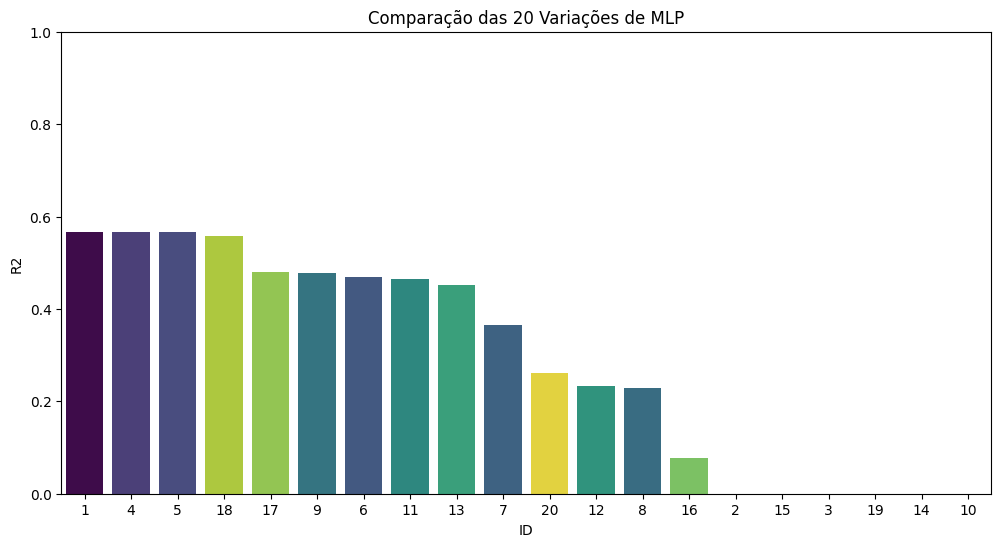

In [23]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

print("--- Testando 20 Variações de MLP ---")
configs_teste = [
    {'id': 1,  'activation': 'tanh', 'hidden_layer_sizes': (6,),      'solver': 'sgd',  'max_iter': 500,  'learning_rate_init': 0.001},
    {'id': 2,  'activation': 'tanh', 'hidden_layer_sizes': (50, 6),   'solver': 'sgd',  'max_iter': 500,  'learning_rate_init': 0.001},
    {'id': 3,  'activation': 'tanh', 'hidden_layer_sizes': (50,),     'solver': 'adam', 'max_iter': 500,  'learning_rate_init': 0.001},
    {'id': 4,  'activation': 'tanh', 'hidden_layer_sizes': (6,),      'solver': 'sgd',  'max_iter': 1000, 'learning_rate_init': 0.001},
    {'id': 5,  'activation': 'tanh', 'hidden_layer_sizes': (6,),      'solver': 'sgd',  'max_iter': 1500, 'learning_rate_init': 0.001},
    {'id': 6,  'activation': 'tanh', 'hidden_layer_sizes': (50,),     'solver': 'sgd',  'max_iter': 500,  'learning_rate_init': 0.001},
    {'id': 7,  'activation': 'tanh', 'hidden_layer_sizes': (50,),     'solver': 'sgd',  'max_iter': 1000, 'learning_rate_init': 0.001},
    {'id': 8,  'activation': 'tanh', 'hidden_layer_sizes': (50,),     'solver': 'sgd',  'max_iter': 1500, 'learning_rate_init': 0.001},
    {'id': 9,  'activation': 'tanh', 'hidden_layer_sizes': (50,),     'solver': 'adam', 'max_iter': 1000, 'learning_rate_init': 0.001},
    {'id': 10, 'activation': 'tanh', 'hidden_layer_sizes': (6,),      'solver': 'adam', 'max_iter': 500,  'learning_rate_init': 0.001},

    {'id': 11, 'activation': 'relu', 'hidden_layer_sizes': (50,),     'solver': 'adam',  'max_iter': 1000, 'learning_rate_init': 0.001},
    {'id': 12, 'activation': 'relu', 'hidden_layer_sizes': (100, 50), 'solver': 'adam',  'max_iter': 1500, 'learning_rate_init': 0.001},
    {'id': 13, 'activation': 'relu', 'hidden_layer_sizes': (50,),     'solver': 'lbfgs', 'max_iter': 1000, 'learning_rate_init': 0.001},
    {'id': 14, 'activation': 'relu', 'hidden_layer_sizes': (100, 50), 'solver': 'lbfgs', 'max_iter': 2000, 'learning_rate_init': 0.001},
    {'id': 15, 'activation': 'tanh', 'hidden_layer_sizes': (100,),    'solver': 'lbfgs', 'max_iter': 1500, 'learning_rate_init': 0.001},
    {'id': 16, 'activation': 'tanh', 'hidden_layer_sizes': (100, 50), 'solver': 'lbfgs', 'max_iter': 2000, 'learning_rate_init': 0.001},
    {'id': 17, 'activation': 'relu', 'hidden_layer_sizes': (200,),    'solver': 'adam',  'max_iter': 1000, 'learning_rate_init': 0.001},
    {'id': 18, 'activation': 'logistic','hidden_layer_sizes':(50,),   'solver': 'adam',  'max_iter': 1000, 'learning_rate_init': 0.001},
    {'id': 19, 'activation': 'relu', 'hidden_layer_sizes': (50,50,50),'solver': 'lbfgs', 'max_iter': 2000, 'learning_rate_init': 0.001},
    {'id': 20, 'activation': 'relu', 'hidden_layer_sizes': (100,),    'solver': 'sgd',   'max_iter': 2000, 'learning_rate_init': 0.01},
]

resultados = []

print(f"{'ID':<3} | {'Solver':<6} | {'Act':<5} | {'Camadas':<12} | {'R2 Score':<10}")
print("-" * 60)

for config in configs_teste:
    # Prepara parâmetros (remove ID)
    params = {k: v for k, v in config.items() if k != 'id'}

    # Treina
    model = MLPRegressor(**params, random_state=42)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Avalia
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    resultados.append({'ID': config['id'], 'R2': r2, 'RMSE': rmse, 'Config': params})

    print(f"{config['id']:<3} | {config['solver']:<6} | {config['activation']:<5} | {str(config['hidden_layer_sizes']):<12} | {r2:.4f}")

df_resultados = pd.DataFrame(resultados).sort_values(by='R2', ascending=False)

print("\n" + "="*30)
print("🏆 TOP 5 MELHORES MODELOS")
print("="*30)
display(df_resultados.head(5))

plt.figure(figsize=(12, 6))

sns.barplot(
    x='ID',
    y='R2',
    data=df_resultados,
    hue='ID',
    palette='viridis',
    order=df_resultados['ID'],
    legend=False
)

plt.title("Comparação das 20 Variações de MLP")
plt.ylim(0, 1.0)
plt.show()

## REGRESSÃO LINEAR

--- Avaliando Regressão Linear ---
Média R² (CV): 0.6059
Desvio Padrão: 0.0237

--- Resultado Final (Teste) ---
R² Score: 0.5947
RMSE:     5.1524


/tmp/ipython-input-3231907963.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Feature', data=coefs, palette='coolwarm')


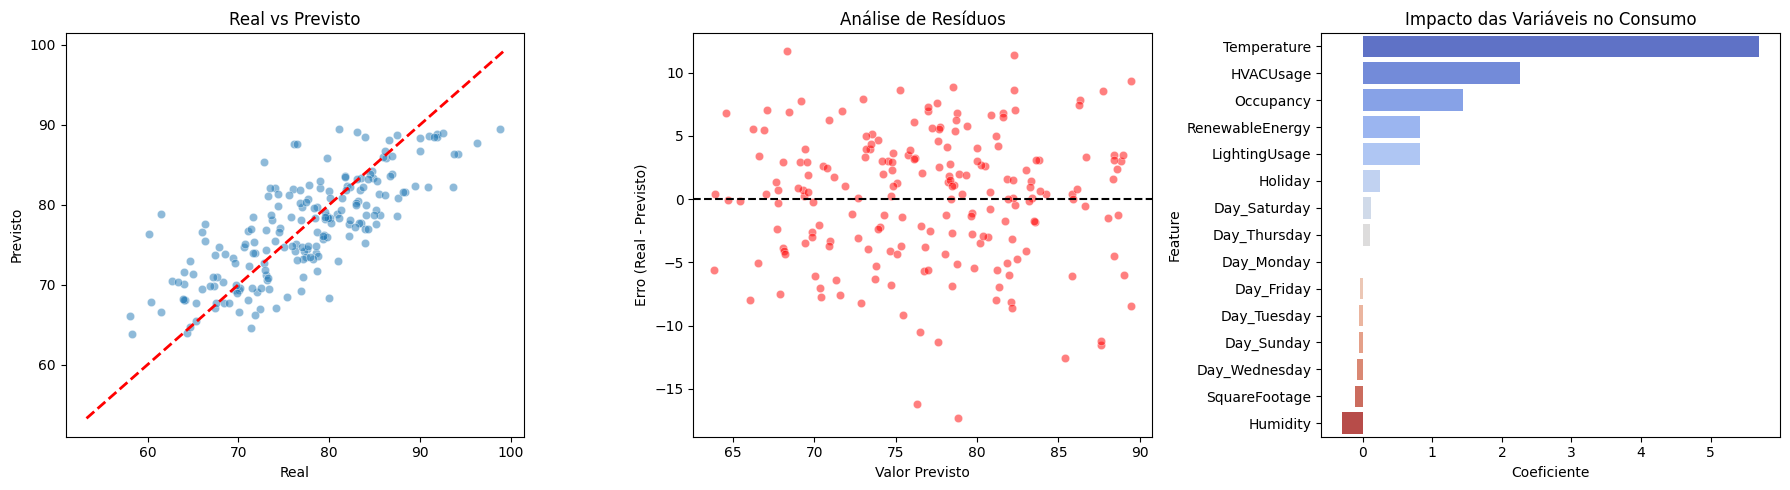

In [24]:
print("--- Avaliando Regressão Linear ---")

# 1. Validação Cruzada (Checando a estabilidade)
model_lr = LinearRegression()
cv_scores = cross_val_score(model_lr, X_train_scaled, y_train, cv=5, scoring='r2')

print(f"Média R² (CV): {cv_scores.mean():.4f}")
print(f"Desvio Padrão: {cv_scores.std():.4f}")

# 2. Treinamento Final
model_lr.fit(X_train_scaled, y_train)

# 3. Previsão no Teste
y_pred_lr = model_lr.predict(X_test_scaled)

# 4. Métricas Finais
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f"\n--- Resultado Final (Teste) ---")
print(f"R² Score: {r2_lr:.4f}")
print(f"RMSE:     {rmse_lr:.4f}")

resultados_finais.append({'Modelo': 'Regressão Linear', 'R2': r2_lr, 'RMSE': rmse_lr})

# --- VISUALIZAÇÕES ---
plt.figure(figsize=(18, 5))

# Gráfico A: Real vs Previsto
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title("Real vs Previsto")
plt.xlabel("Real")
plt.ylabel("Previsto")

# Gráfico B: Resíduos
residuos = y_test - y_pred_lr
plt.subplot(1, 3, 2)
sns.scatterplot(x=y_pred_lr, y=residuos, alpha=0.5, color='red')
plt.axhline(y=0, color='black', linestyle='--')
plt.title("Análise de Resíduos")
plt.xlabel("Valor Previsto")
plt.ylabel("Erro (Real - Previsto)")

# Gráfico C: Importância das Variáveis (Coeficientes)
# Mostra o que aumenta ou diminui o consumo
plt.subplot(1, 3, 3)
coefs = pd.DataFrame({
    'Feature': X.columns,
    'Coeficiente': model_lr.coef_
}).sort_values(by='Coeficiente', ascending=False)

sns.barplot(x='Coeficiente', y='Feature', data=coefs, palette='coolwarm')
plt.title("Impacto das Variáveis no Consumo")

plt.tight_layout()
plt.show()

## RANDOM FOREST

--- Otimizando Random Forest com Validação Cruzada ---
Árvores  | Média R² (CV)  
------------------------------
10       | 0.5113
50       | 0.5417
100      | 0.5474
150      | 0.5499
200      | 0.5507
300      | 0.5518
400      | 0.5512
500      | 0.5508
600      | 0.5515
700      | 0.5515
800      | 0.5521
900      | 0.5526
1000     | 0.5532
------------------------------
🏆 MELHOR Configuração (no Treino): 1000 árvores (Média R²: 0.5532)

Treinando modelo final com 1000 árvores...
R² Final (no Teste): 0.5492
RMSE Final: 5.4341


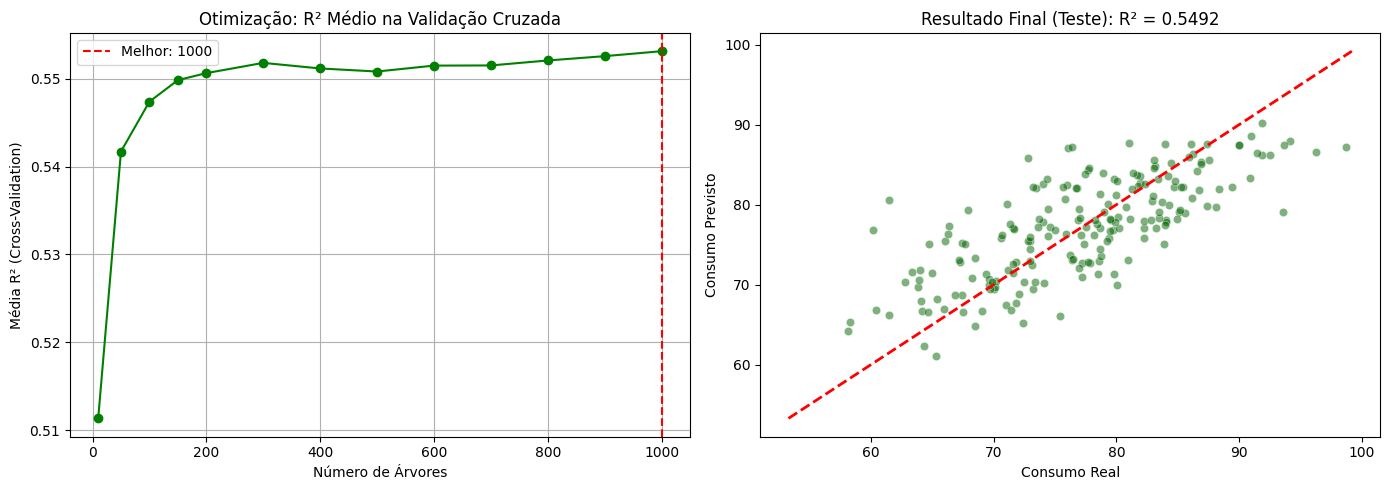

In [25]:
print("--- Otimizando Random Forest com Validação Cruzada ---")

# Lista de estimadores para testar
lista_estimators = [10, 50, 100, 150, 200, 300, 400, 500, 600, 700, 800, 900, 1000]

# Listas para armazenar o histórico
est_values = []
cv_mean_values = [] # Média do R2 na validação cruzada

best_est = 0
best_cv_score = -np.inf

print(f"{'Árvores':<8} | {'Média R² (CV)':<15}")
print("-" * 30)

# 1. Loop de Otimização (Usando apenas dados de TREINO com CV)
for n in lista_estimators:
    # Define o modelo
    model = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)

    # Aplica validação cruzada (5 dobras)
    # Isso treina 5 vezes e valida 5 vezes para cada 'n'
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    mean_score = scores.mean()

    # Guardar para o gráfico
    est_values.append(n)
    cv_mean_values.append(mean_score)

    print(f"{n:<8} | {mean_score:.4f}")

    # Verificar se é o melhor até agora baseado na média
    if mean_score > best_cv_score:
        best_cv_score = mean_score
        best_est = n

print("-" * 30)
print(f"🏆 MELHOR Configuração (no Treino): {best_est} árvores (Média R²: {best_cv_score:.4f})")

# 2. Treinamento Final e Teste Real
# Agora que sabemos o melhor número de árvores, treinamos o modelo final
print(f"\nTreinando modelo final com {best_est} árvores...")
final_model = RandomForestRegressor(n_estimators=best_est, random_state=42, n_jobs=-1)
final_model.fit(X_train_scaled, y_train)

# Previsão nos dados de TESTE
y_pred_final = final_model.predict(X_test_scaled)

# Métricas Finais
final_r2 = r2_score(y_test, y_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))

print(f"R² Final (no Teste): {final_r2:.4f}")
print(f"RMSE Final: {final_rmse:.4f}")

# 3. Guardar na lista final
resultados_finais.append({
    'Modelo': f'Random Forest (n={best_est})',
    'R2': final_r2,
    'RMSE': final_rmse
})

# --- GRÁFICOS ---
plt.figure(figsize=(14, 5))

# Gráfico 1: Curva de Aprendizado (Baseado na Validação Cruzada)
plt.subplot(1, 2, 1)
plt.plot(est_values, cv_mean_values, marker='o', linestyle='-', color='green')
plt.title('Otimização: R² Médio na Validação Cruzada')
plt.xlabel('Número de Árvores')
plt.ylabel('Média R² (Cross-Validation)')
plt.axvline(x=best_est, color='red', linestyle='--', label=f'Melhor: {best_est}')
plt.legend()
plt.grid(True)

# Gráfico 2: Real vs Previsto (Modelo Final no Teste)
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred_final, alpha=0.5, color='darkgreen')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title(f"Resultado Final (Teste): R² = {final_r2:.4f}")
plt.xlabel("Consumo Real")
plt.ylabel("Consumo Previsto")

plt.tight_layout()
plt.show()

## NAIVE BAYES


--- Avaliando Regressão Bayesiana (Substituto do Naive Bayes) ---
Média R² (CV): 0.6061
Desvio Padrão: 0.0225

--- Resultado Final (Teste) ---
R² Score: 0.5947
RMSE:     5.1526


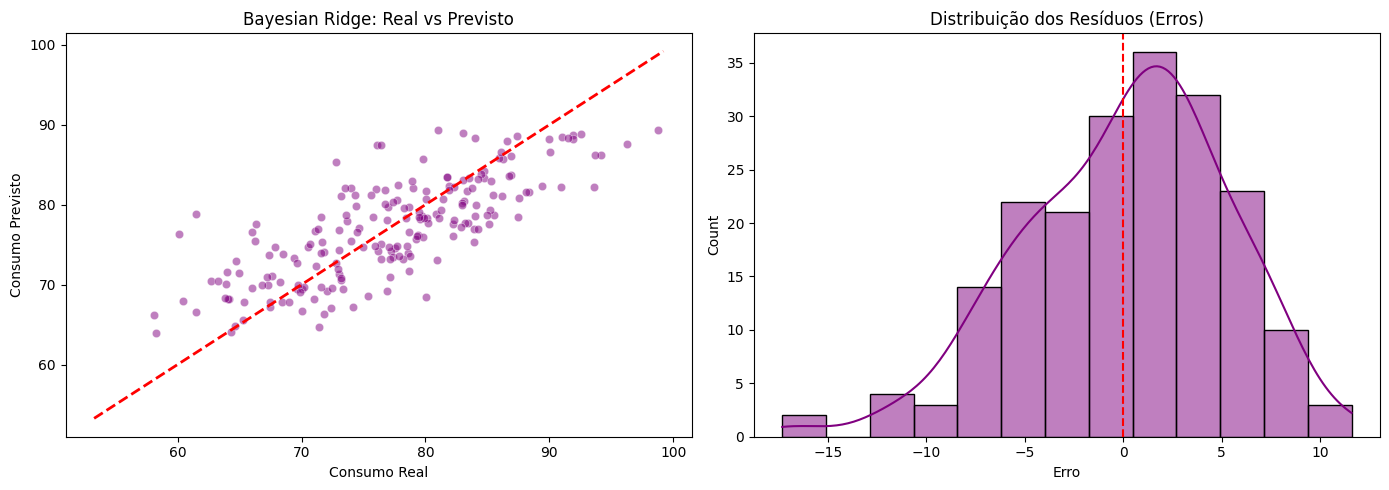

In [26]:
print("--- Avaliando Regressão Bayesiana (Substituto do Naive Bayes) ---")

# 1. Instanciar o Modelo
model_bayes = BayesianRidge()

# 2. Validação Cruzada (Cross-Validation)
cv_scores = cross_val_score(model_bayes, X_train_scaled, y_train, cv=5, scoring='r2')

print(f"Média R² (CV): {cv_scores.mean():.4f}")
print(f"Desvio Padrão: {cv_scores.std():.4f}")

# 3. Treinamento Final
model_bayes.fit(X_train_scaled, y_train)

# 4. Previsão no Teste
y_pred_bayes = model_bayes.predict(X_test_scaled)

# 5. Métricas Finais
r2_bayes = r2_score(y_test, y_pred_bayes)
rmse_bayes = np.sqrt(mean_squared_error(y_test, y_pred_bayes))

print(f"\n--- Resultado Final (Teste) ---")
print(f"R² Score: {r2_bayes:.4f}")
print(f"RMSE:     {rmse_bayes:.4f}")

# Guardar resultado na lista geral
resultados_finais.append({'Modelo': 'Bayesian Ridge', 'R2': r2_bayes, 'RMSE': rmse_bayes})

# --- GRÁFICOS ---
plt.figure(figsize=(14, 5))

# Gráfico 1: Real vs Previsto
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_bayes, alpha=0.5, color='purple')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title("Bayesian Ridge: Real vs Previsto")
plt.xlabel("Consumo Real")
plt.ylabel("Consumo Previsto")

# Gráfico 2: Distribuição de Erros
residuos = y_test - y_pred_bayes
plt.subplot(1, 2, 2)
sns.histplot(residuos, kde=True, color='purple')
plt.axvline(x=0, color='r', linestyle='--')
plt.title("Distribuição dos Resíduos (Erros)")
plt.xlabel("Erro")

plt.tight_layout()
plt.show()

### Salvando o melhor modelo

In [27]:
joblib.dump(model_lr, "ecoagent_linear_model.pkl")
joblib.dump(scaler, "ecoagent_scaler.pkl")

['ecoagent_scaler.pkl']